In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import re
import string

In [ ]:
fake_path = "/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv"
true_path = "/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv"

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

print("Fake shape:", fake_df.shape)
print("True shape:", true_df.shape)

In [ ]:
fake_df.head()

In [ ]:
true_df.head()

In [ ]:
fake_df["label"] = 0
true_df["label"] = 1

df = pd.concat([fake_df, true_df], axis=0)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df["label"].value_counts())

In [ ]:
df["content"] = df["title"] + " " + df["text"]

df[["content", "label"]].head()

In [ ]:
print(df.isnull().sum())

In [ ]:
df = df.dropna(subset=["content", "label"])
print(df.isnull().sum())

In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
df["content"] = df["content"].apply(clean_text)

df[["content", "label"]].head()

In [ ]:
X = df["content"]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000
max_len = 300

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print(X_train_pad.shape)
print(X_test_pad.shape)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "/kaggle/working/best_lstm_model.keras",
    monitor="val_loss",
    save_best_only=True
)

history = model.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

In [ ]:
import pickle
import json

# 1) Tokenizer'ı kaydet
with open("/kaggle/working/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# 2) Config kaydet (modeli tekrar kullanmak için kritik)
config = {
    "max_words": max_words,
    "max_len": max_len,
    "label_mapping": {
        "fake": 0,
        "real": 1
    }
}

with open("/kaggle/working/lstm_config.json", "w") as f:
    json.dump(config, f)

print("Tokenizer ve config başarıyla kaydedildi.")

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/kaggle/working/best_lstm_model.keras")

test_loss, test_accuracy = best_model.evaluate(X_test_pad, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = best_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32")

print(classification_report(y_test, y_pred, target_names=["Fake", "Real"]))

cm = confusion_matrix(y_test, y_pred)
print(cm)

In [ ]:
import json
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Metrikleri hesapla
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"],
    output_dict=True
)

cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# 1) Classification report CSV
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv("/kaggle/working/lstm_classification_report.csv", index=True)

# 2) Confusion matrix CSV
cm_df = pd.DataFrame(
    cm,
    index=["Actual Fake", "Actual Real"],
    columns=["Predicted Fake", "Predicted Real"]
)
cm_df.to_csv("/kaggle/working/lstm_confusion_matrix.csv", index=True)

# 3) Genel sonuç JSON
results = {
    "model": "LSTM",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "total_test_samples": int(len(y_test)),
    "total_errors": int((y_test.values.reshape(-1, 1) != y_pred).sum()),
    "confusion_matrix": cm.tolist()
}

with open("/kaggle/working/lstm_test_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Sonuç dosyaları kaydedildi:")
print("/kaggle/working/lstm_classification_report.csv")
print("/kaggle/working/lstm_confusion_matrix.csv")
print("/kaggle/working/lstm_test_results.json")

In [ ]:
def predict_news(text):
    # 1) Aynı cleaning işlemi
    cleaned_text = clean_text(text)
    
    # 2) Aynı tokenizer ile sayıya çevir
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    
    # 3) Aynı max_len ile padding
    padded = pad_sequences(sequence, maxlen=max_len, padding="post", truncating="post")
    
    # 4) Tahmin
    prob = best_model.predict(padded)[0][0]
    
    # 5) Label yorumu
    if prob >= 0.5:
        label = "REAL"
    else:
        label = "FAKE"
    
    print("Prediction:", label)
    print("Real probability:", prob)
    print("Fake probability:", 1 - prob)

In [ ]:
sample_news = """
NASA announced Friday Janet Petro, center director for the agency’s Kennedy Space Center in Florida, is retiring.

Prior to joining NASA, Petro worked in a variety of military and industry positions, ultimately beginning her career at the agency in 2007 and working her way up to center director, as well as serving as acting administrator from January to July 2025.

“From the outset of her distinguished tenure at NASA, Janet has served as a profoundly influential leader, guiding both the agency and our Kennedy Space Center through some of the most significant transitions in our shared history, including playing a central role in reshaping NASA Kennedy into the nation’s premier multiuser spaceport,” said NASA Administrator Jared Isaacman. “As NASA has been charged, once again, with accomplishing the near impossible, I’m grateful for Janet for always embracing the challenge of discovering what could be and for pushing the boundaries to deliver the missions that enable NASA to lead the way into a new era of space.”
"""

predict_news(sample_news)

In [ ]:
import json
import matplotlib.pyplot as plt

sample_news = """
NASA announced Friday Janet Petro, center director for the agency’s Kennedy Space Center in Florida, is retiring.

Prior to joining NASA, Petro worked in a variety of military and industry positions, ultimately beginning her career at the agency in 2007 and working her way up to center director, as well as serving as acting administrator from January to July 2025.

“From the outset of her distinguished tenure at NASA, Janet has served as a profoundly influential leader, guiding both the agency and our Kennedy Space Center through some of the most significant transitions in our shared history, including playing a central role in reshaping NASA Kennedy into the nation’s premier multiuser spaceport,” said NASA Administrator Jared Isaacman. “As NASA has been charged, once again, with accomplishing the near impossible, I’m grateful for Janet for always embracing the challenge of discovering what could be and for pushing the boundaries to deliver the missions that enable NASA to lead the way into a new era of space.”
"""

# Tahmin işlemi
cleaned_text = clean_text(sample_news)
sequence = tokenizer.texts_to_sequences([cleaned_text])
padded = pad_sequences(sequence, maxlen=max_len, padding="post", truncating="post")

prob_real = float(best_model.predict(padded)[0][0])
prob_fake = float(1 - prob_real)

prediction = "REAL" if prob_real >= 0.5 else "FAKE"

external_result = {
    "model": "LSTM",
    "sample_news": sample_news.strip(),
    "prediction": prediction,
    "real_probability": prob_real,
    "fake_probability": prob_fake,
    "label_mapping": {
        "FAKE": 0,
        "REAL": 1
    }
}

# 1) JSON olarak kaydet
with open("/kaggle/working/lstm_external_test_result.json", "w") as f:
    json.dump(external_result, f, indent=4)

# 2) TXT rapor olarak kaydet
with open("/kaggle/working/lstm_external_test_result.txt", "w") as f:
    f.write("LSTM External News Test Result\n")
    f.write("=" * 35 + "\n\n")
    f.write(f"Prediction: {prediction}\n")
    f.write(f"Real Probability: {prob_real:.6f}\n")
    f.write(f"Fake Probability: {prob_fake:.6f}\n\n")
    f.write("Sample News:\n")
    f.write(sample_news.strip())

# 3) Görsel olarak kaydet
plt.figure(figsize=(8, 5))
plt.bar(["FAKE", "REAL"], [prob_fake, prob_real])
plt.ylim(0, 1)
plt.title("LSTM External News Prediction")
plt.ylabel("Probability")

plt.text(0, prob_fake + 0.03, f"{prob_fake:.4f}", ha="center")
plt.text(1, prob_real + 0.03, f"{prob_real:.4f}", ha="center")

plt.figtext(
    0.5,
    0.01,
    f"Prediction: {prediction}",
    ha="center",
    fontsize=12
)

plt.tight_layout()
plt.savefig("/kaggle/working/lstm_external_test_result.png", dpi=300)
plt.show()

print("Kaydedilen dosyalar:")
print("/kaggle/working/lstm_external_test_result.json")
print("/kaggle/working/lstm_external_test_result.txt")
print("/kaggle/working/lstm_external_test_result.png")

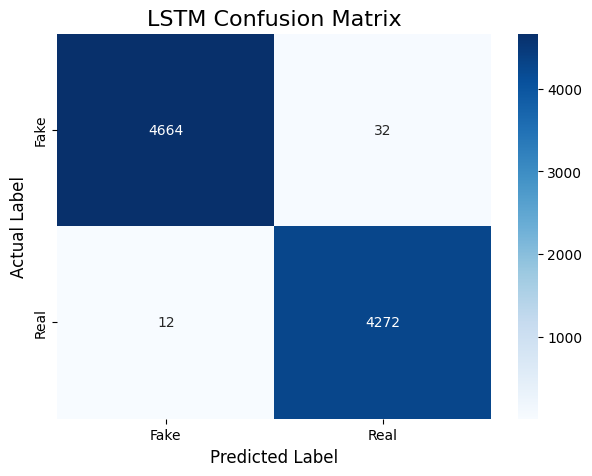

PNG kaydedildi:
/kaggle/working/lstm_confusion_matrix.png


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion matrix oluştur
cm = confusion_matrix(y_test, y_pred)

# Görsel boyutu
plt.figure(figsize=(7, 5))

# Heatmap çiz
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

# Başlık ve etiketler
plt.title("LSTM Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)

# PNG olarak kaydet
plt.savefig(
    "/kaggle/working/lstm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

# Göster
plt.show()

print("PNG kaydedildi:")
print("/kaggle/working/lstm_confusion_matrix.png")

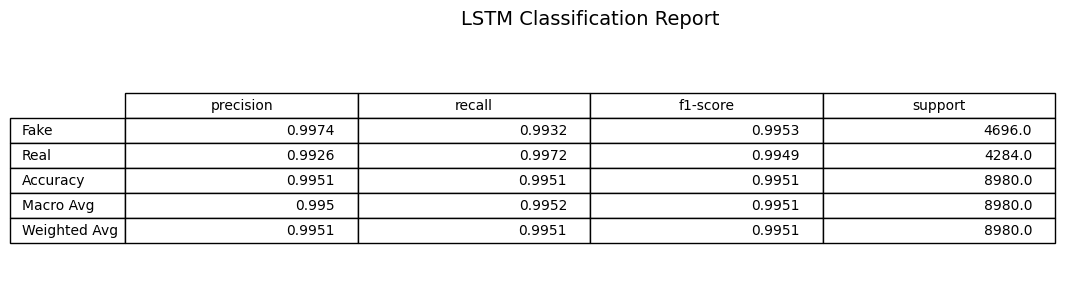

PNG kaydedildi:
/kaggle/working/lstm_classification_report.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Classification report değerleri
data = {
    "precision": [0.9974, 0.9926, 0.9951, 0.9950, 0.9951],
    "recall":    [0.9932, 0.9972, 0.9951, 0.9952, 0.9951],
    "f1-score":  [0.9953, 0.9949, 0.9951, 0.9951, 0.9951],
    "support":   [4696, 4284, 8980, 8980, 8980]
}

index_labels = [
    "Fake",
    "Real",
    "Accuracy",
    "Macro Avg",
    "Weighted Avg"
]

# DataFrame oluştur
report_df = pd.DataFrame(data, index=index_labels)

# Figure oluştur
fig, ax = plt.subplots(figsize=(10, 3))

# Eksenleri kapat
ax.axis("off")

# Tablo oluştur
table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    loc="center"
)

# Stil ayarları
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Başlık
plt.title("LSTM Classification Report", fontsize=14, pad=20)

# PNG kaydet
plt.savefig(
    "/kaggle/working/lstm_classification_report.png",
    dpi=300,
    bbox_inches="tight"
)

# Göster
plt.show()

print("PNG kaydedildi:")
print("/kaggle/working/lstm_classification_report.png")